Dataframe de viajes registrados
      Viaje_id        Dia      Clima Metodo_pago  Costo  Propina
0    TRIP-0001  Miercoles  Despejado     Tarjeta   7.96     0.32
1    TRIP-0002     Sabado  Despejado    Efectivo  11.81     0.46
2    TRIP-0003     Sabado  Despejado    Efectivo  20.28     2.26
3    TRIP-0004    Viernes  Despejado    Efectivo  13.04     1.10
4    TRIP-0005      Lunes  Despejado     Tarjeta   8.86     1.83
..         ...        ...        ...         ...    ...      ...
595  TRIP-0596    Viernes   Tormenta    Efectivo  35.23     1.29
596  TRIP-0597    Viernes   Tormenta     Tarjeta  38.45     2.43
597  TRIP-0598      Lunes   Tormenta    Efectivo  26.84     2.55
598  TRIP-0599      Lunes     Lluvia    Efectivo  18.28     2.12
599  TRIP-0600      Lunes  Despejado    Efectivo  15.21     0.06

[600 rows x 6 columns]

Analisis Multivariado (Group by: Clima y Dia de la semana)

        Clima        Dia   Promedio  Mediana  Desviacion_std  Total_viaje
0   Despejado      Lunes  12.

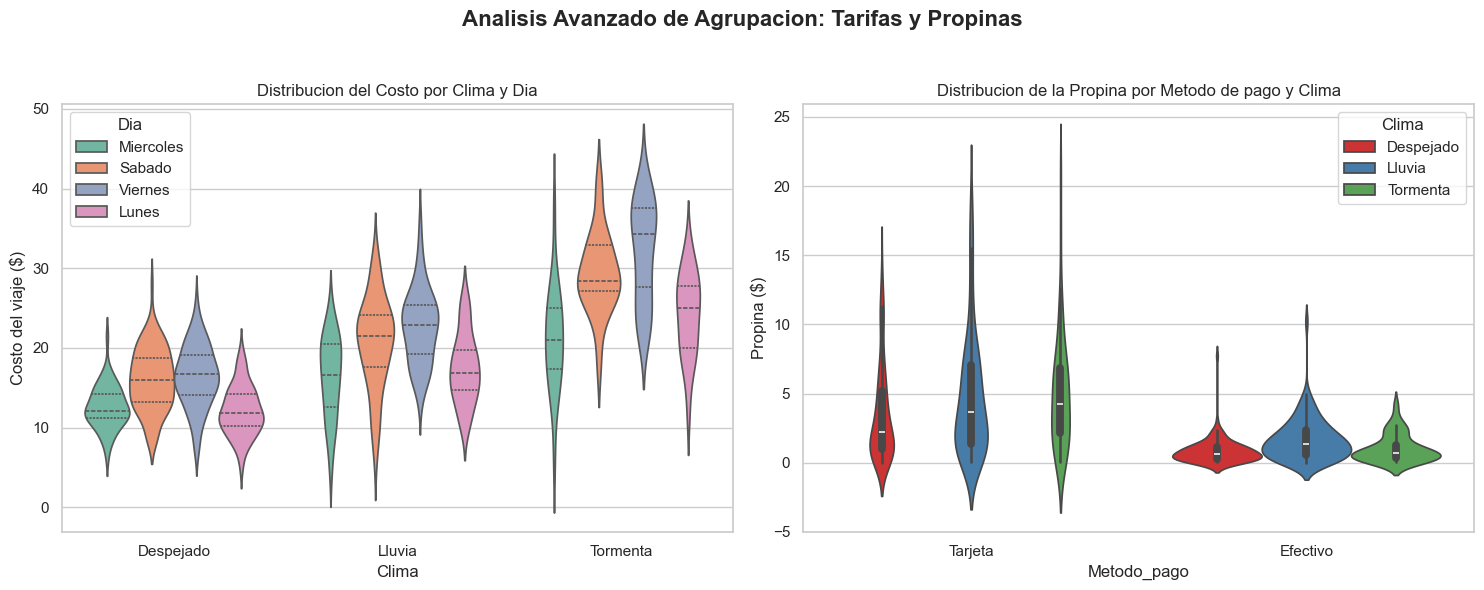

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#configuracion visual template
sns.set_theme(style="whitegrid")

#crear set de datos de viajes en uber 
np.random.seed(42)
n_viajes=600
#el choice me seleccionar de los elementos de la lista un elemento al azar para cada viaje 
#                      20%       20%         40%        30%                  probabilidad de seleccionar cada dia
dias=np.random.choice(['Lunes','Miercoles','Viernes','Sabado'],size=n_viajes,p=[0.2,0.2,0.3,0.3])
clima=np.random.choice(['Despejado','Lluvia','Tormenta'],size=n_viajes,p=[0.5,0.35,0.15])
metodo_pago=np.random.choice(['Efectivo','Tarjeta'],size=n_viajes,p=[0.4,0.6])
#                          precio promedio,desviacion standar, tamanio 
costo_base=np.random.normal(loc=12.0,scale=3.0,size=n_viajes)
#si ese dia llueve entonces aumenta el 40% a la tarifa, si ese dia es tormenta aumenta un 90% el precio,
# si cualquier otro clima que no sea tormenta o lluvia el precio se va a mantener  igual
multiplicador_clima=np.where(clima=='Lluvia',1.4,np.where(clima=='Tormenta',1.9,1.0))
#si el dia es viernes o es sabado entonces la tarifa aumentara en un 30% si no se va a mantener igual
multiplicador_dia=np.where((dias=='Viernes')|(dias=='Sabado'),1.30,1.0)
#el maximum compara cada resultado que se genere si el resultado que me da por ejem fuera 2.8 entonces lo va a sustituir por el 5, 
# otro ejem si el resultado que da fuera 7.2 entonces va a mantener el 7.2 
#calcula el costo total de cada viaje asegurandose que ningun viaje menos de 5 dolares 
costo_total=np.maximum(5.0,costo_base*multiplicador_clima*multiplicador_dia)
#genera propina aleatorio, si paga con tarjeta entonces el promedio que me de propina de 3.5, 
# si no es tarjeta entonces el promedio es que me de 1 dolar de propina 
propina_base=np.where(metodo_pago=='Tarjeta',np.random.exponential(scale=3.5,size=n_viajes),np.random.exponential(scale=1.0,size=n_viajes))
#cual quier clima diferente de despejado, la propia base se multiplicara por 1.5, 
# si es despejado entonces la propina base se mantiene igual 
propina_total=np.round(np.where(clima!='Despejado',propina_base*1.5,propina_base),2)
df_viajes=pd.DataFrame({
    
    'Viaje_id':[f"TRIP-{i:04}"for i in range(1,n_viajes+1)],
    'Dia':dias,
    'Clima':clima,
    'Metodo_pago':metodo_pago,
    'Costo':np.round(costo_total,2),
    'Propina':propina_total
    
})

print("Dataframe de viajes registrados")
print(df_viajes)
print()

#creacion del group by
print("Analisis Multivariado (Group by: Clima y Dia de la semana)")
print()
#esta es una tabla de resumen de costo que se esta agrupando segun el clima y el dia 
# el costo indica que los calculos que se haran se van aplicar sobre esa columna de costo 
# y lo q se coloca dentro de agg() son las funciones estadistica q quiero que se calcule 
groupby_resumen=df_viajes.groupby(['Clima','Dia'])['Costo'].agg(
    
    Promedio='mean',
    Mediana='median',
    Desviacion_std='std',
    Total_viaje='count',
    
#lo que hace es que convierte clima y dia nuevamente como columnas normales es el DF, 
#si yo no le pongo este reset entonces clima y dia van a quedar como indices del resultado 
).reset_index()
print(groupby_resumen)
print()

#crear pivot table
print("Pivot Table: (Costo promedio por Clima vs Dia)")
print()
pivot_costo=df_viajes.pivot_table(
    
    values='Costo',#varia a analizar 
    index='Clima',#filas 
    columns='Dia',
    aggfunc='mean',#funcion de agregacion de promedio
    
)
print(np.round(pivot_costo,2))
print()

#visualizacion avanzada (violin plots)
fig,axes=plt.subplots(1,2,figsize=(15,6))
fig.suptitle('Analisis Avanzado de Agrupacion: Tarifas y Propinas',fontsize=16,fontweight='bold')

#violina plot 1:
sns.violinplot(
    
    data=df_viajes,
    x='Clima',
    y='Costo',
    hue='Dia',
    ax=axes[0],
    palette='Set2',
    inner='quartile',
    
)

axes[0].set_title('Distribucion del Costo por Clima y Dia')
axes[0].set_ylabel('Costo del viaje ($)')

#violin plot 2: Propina segun metodo de pago y clima
sns.violinplot(
    
    data=df_viajes,
    x='Metodo_pago',
    y='Propina',
    hue='Clima',
    ax=axes[1],
    palette='Set1',
    split=False,# representa con sus propio violin 
    inner='box',# diagrama de caja dentro de cada violin
    
)
axes[1].set_title('Distribucion de la Propina por Metodo de pago y Clima')
axes[1].set_ylabel('Propina ($)')

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


Diagnostico

El clima es el principal factor de la tarifa. En condiciones de tormenta, el costo del viaje se incrementa considerablemente, alcanzado valores promedio los fines de semana de hasta 32$.

los dias de mayor demanda son los viernes y los sabados independientemente del factor clima.

Los usuarios que pagan con tarjeta otorgan mas propinas que los pagan en efectivo.
En el caso de pagos en efectivo la mayor concentracion se encuentra entre 1 y 2$ de propina.


AGREGADO MIO:



| Graficamente                | Qué significa                                          |
| --------------------------- | ------------------------------------------------------ |
| **Más gordo**               | Hay más datos concentrados ahí                         |
| **Más delgado**             | Hay menos datos ahí                                    |
| **Línea central**           | Mediana                                                |
| **Líneas arriba/abajo**     | Cuartiles                                              |
| **Más alto**                | Valores más altos / mayor rango                        |
| **Más bajo**                | Valores más bajos                                      |
| **Violines muy separados**  | Las distribuciones tienen valores centrales diferentes |
| **Violines que se parecen** | Distribuciones más similares                           |

